## PaleoExfiltration Model Code (Retreat-Readvance Time Series) ##

##### This code has been adapted from Robel et al. (2023). 

### Load in packages to run hydromechanical model and plot

In [17]:
# Load in necessary packages 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as spr
from scipy.sparse.linalg import inv
from pyproj import Proj, transform

In [18]:
# Loading in the interpolated data frame produced in the PreExfiltration.ipynb or PreExfiltrationSpline.ipynb
file_path ='retreatreadvancetimeseries.csv'
interpolated_df = pd.read_csv(file_path)

# Calculate the duration for each site
duration_tf = interpolated_df.groupby('Site ').agg(
    Start_Age=('Age', 'max'),
    End_Age=('Age', 'min'),
    Duration=('Age', lambda x: x.max() - x.min())
).reset_index()

# Display the first few rows of the duration data
duration_tf.head()

,Site,Start_Age,End_Age,Duration
0,1,8.1,0.0,8.1


# Specify time-dependent load change

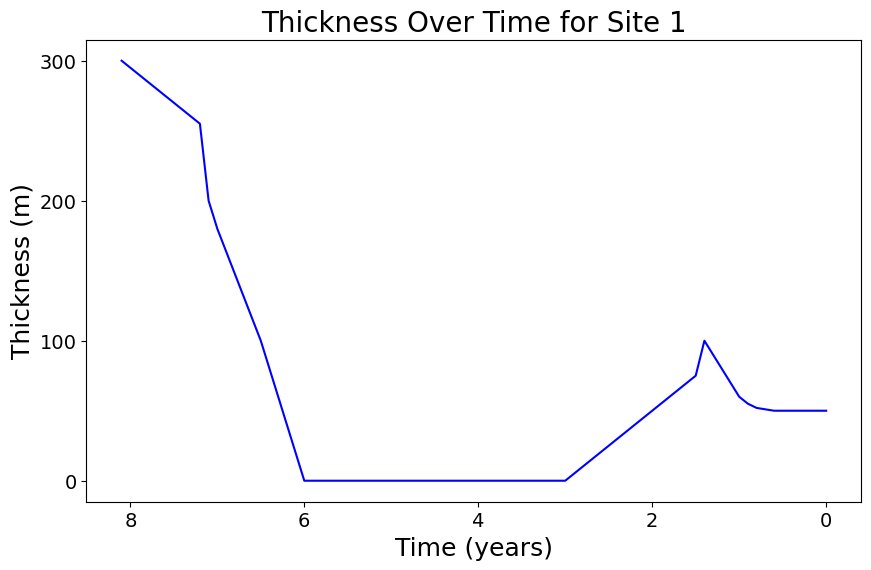

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(site_data['Age'], site_data['Thickness'], color='blue')
plt.xlabel('Time (years)', fontsize=18)  # Increase the font size
plt.ylabel('Thickness (m)', fontsize=18)  # Increase the font size
plt.title(f'Thickness Over Time for Site {site}', fontsize=20)  # Increase the font size
plt.gca().invert_xaxis()  # Invert x-axis so that time decreases to the right

# Customize ticks
plt.xticks(fontsize=14)  # Set x-axis tick font size
plt.yticks(fontsize=14)  # Set y-axis tick font size

# Reduce the number of ticks
plt.locator_params(axis='x', nbins=5)  # Fewer ticks on the x-axis
plt.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

plt.show()

# Load in packages to extract relevant field and map exfiltration predictions

In [20]:
import xarray as xr
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as colors
import cmocean
import scipy.io as sio
import geopandas as gpd
import rioxarray
import zipfile

### Calculate Exfiltration Prediction (plus plot)

In [21]:
# Constants
year = 3600 * 24 * 365  # seconds in a year
rhoi = 920  # density of glacier ice (kg/m3)
rhow = 1000  # density of water (kg/m3)
g = 9.81  # acceleration due to gravity (m/s2)
mu_w = 1e-3  # viscosity of water (Pa*s)
perm = 1e-13  # permeability (m^2)
K_t = perm * rhow * g / mu_w  # hydraulic conductivity (m/s)
S = 1e-4  # sediment specific storage capacity (m-1)
xi = 0.2  # Skempton's constant (dimensionless)
deltat = (site_data['Age'].max() - site_data['Age'].min()) # time increment based on the site's age range

# Calculate dhdt (rate of change of ice thickness)
dhdt = np.gradient(site_data['Thickness'], site_data['Age'])

# Calculate the exfiltration rate for the selected site
exfil_analytic = 2 * (1 - xi) * (rhoi / rhow) * dhdt * (K_t * S * deltat / np.pi) ** 0.5
exfil_value = exfil_analytic * 1000  # Convert to mm/yr

dH/dt range: -550 to 250 m/kyr


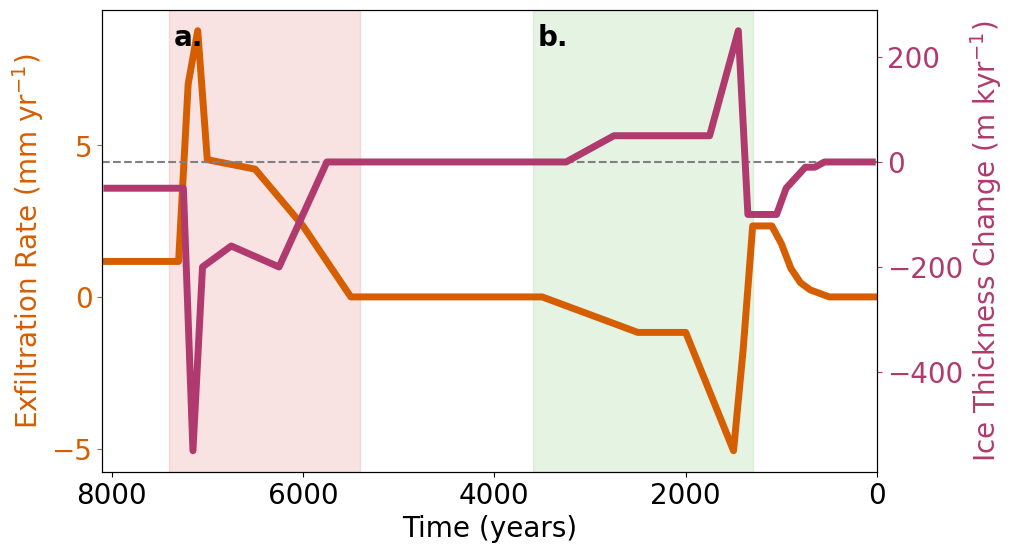

In [29]:
import numpy as np
import matplotlib.pyplot as plt

line_width = 5

# Align to one ordering (past → present)
order = np.argsort(-site_data['Age'].to_numpy(float))
age_kyr = site_data['Age'].to_numpy(float)[order]      # kyr
thk     = site_data['Thickness'].to_numpy(float)[order]
exf     = np.asarray(exfil_value, dtype=float)[order]

# Make sure things are in kyr
dt   = age_kyr[:-1] - age_kyr[1:]                      # kyr
dHdt = (thk[1:] - thk[:-1]) / dt                       # m kyr⁻¹, negative = thinning
mid  = (age_kyr[:-1] + age_kyr[1:]) / 2

# Plot in years to match the original axis
fig, ax1 = plt.subplots(figsize=(10, 6))

line1, = ax1.plot(age_kyr * 1000, exf, '-', color="#D55E00",
                  label='Exfiltration Rate', linewidth=line_width)
ax1.set_xlabel('Time (years)', fontsize=20)
ax1.set_ylabel('Exfiltration Rate (mm yr$^{-1}$)', fontsize=20, color="#D55E00")
ax1.tick_params(axis='y', labelsize=20, colors="#D55E00")
ax1.tick_params(axis='x', labelsize=20)
ax1.invert_xaxis()
ax1.set_xlim(8100, 0)
ax1.locator_params(axis='x', nbins=5)
ax1.locator_params(axis='y', nbins=5)

ax2 = ax1.twinx()
line2, = ax2.plot(mid * 1000, dHdt, color="#B03A6E",
                  label='Ice Thickness Change', linewidth=line_width)
ax2.set_ylabel('Ice Thickness Change (m kyr$^{-1}$)', fontsize=20, color="#B03A6E")
ax2.tick_params(axis='y', labelsize=20, colors="#B03A6E")
ax2.locator_params(axis='y', nbins=5)
ax2.axhline(0, color='grey', linestyle='--', linewidth=1.5, zorder=0)

ax1.axvspan(7400, 5400, color='#E8A0A0', alpha=0.30, zorder=0)
ax1.axvspan(3600, 1300, color='#A8D8A0', alpha=0.30, zorder=0)
ax1.text(7350, ax1.get_ylim()[1]*0.95, 'a.', fontsize=20, fontweight='bold', va='top')
ax1.text(3550, ax1.get_ylim()[1]*0.95, 'b.', fontsize=20, fontweight='bold', va='top')
plt.savefig("exfiltrationcomplexperm13.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
import numpy as np

# Convert to arrays (in case they're pandas objects)
exfil_arr = np.asarray(exfil_value)
age_arr = np.asarray(site_data['Age'])

# Index of maximum exfiltration
imax = np.nanargmax(exfil_arr)

max_exfil = exfil_arr[imax]
max_age = age_arr[imax]

# Optional: define a time interval (between neighboring points)
if 0 < imax < len(age_arr) - 1:
    time_interval = (age_arr[imax + 1], age_arr[imax - 1])
else:
    time_interval = (max_age, max_age)

print(f"Max exfiltration rate: {max_exfil:.3f} mm/yr")
print(f"Occurs at age: {max_age:.2f} kyr")
print(f"Time interval: {time_interval[0]:.2f}–{time_interval[1]:.2f} kyr")


Max exfiltration rate: 8.779 mm/yr
Occurs at age: 7.10 kyr
Time interval: 7.00–7.20 kyr


In [34]:
# Convert to arrays (in case they're pandas objects)
exfil_arr = np.asarray(exfil_value)
age_arr = np.asarray(site_data['Age'])

# Index of minimum (most negative) exfiltration
imin = np.nanargmin(exfil_arr)
min_exfil = exfil_arr[imin]
min_age = age_arr[imin]

# Define time interval using neighboring points
if 0 < imin < len(age_arr) - 1:
    time_interval = (age_arr[imin + 1], age_arr[imin - 1])
else:
    time_interval = (min_age, min_age)

print(f"Most negative exfiltration rate: {min_exfil:.3f} mm/yr")
print(f"Occurs at age: {min_age:.2f} kyr")
print(f"Time interval: {time_interval[0]:.2f}–{time_interval[1]:.2f} kyr")


Most negative exfiltration rate: -5.072 mm/yr
Occurs at age: 1.50 kyr
Time interval: 1.40–2.00 kyr
